<a href="https://colab.research.google.com/github/Uttaran1997/movie-recommender-svd./blob/main/notebooks/01%20ratings%20matrix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
movies = ["Action 1", "Action 2", "Action 3",
          "Romance 1", "Romance 2", "Romance 3"]

users = ["Ana", "Ben", "Cal", "Dee", "Eve", "Fay"]

These are labels, not the matrix itself:
- movies labels the six columns.
- users labels the six rows.

In [3]:
toy = np.array([
    [5, 4, 5, 1, np.nan, 2],          # Ana
    [4, np.nan, 5, 2, 1, 1],          # Ben
    [5, 5, np.nan, 1, 2, np.nan],     # Cal
    [1, 2, 1, 5, 4, np.nan],          # Dee
    [np.nan, 1, 2, 4, 5, 5],          # Eve
    [2, 1, np.nan, 5, np.nan, 4],     # Fay
])

This is the \(6\times6\) ratings matrix. Each row corresponds to the matching person in users; each column corresponds to the matching movie in movies.
np.nan means “not a number.” Here we deliberately use it to represent a movie the person has not rated.

In [4]:
toy_table = pd.DataFrame(toy, index=users, columns=movies)
toy_table

,Action 1,Action 2,Action 3,Romance 1,Romance 2,Romance 3
Ana,5.0,4.0,5.0,1.0,NaN,2.0
Ben,4.0,NaN,5.0,2.0,1.0,1.0
Cal,5.0,5.0,NaN,1.0,2.0,NaN
Dee,1.0,2.0,1.0,5.0,4.0,NaN
Eve,NaN,1.0,2.0,4.0,5.0,5.0
Fay,2.0,1.0,NaN,5.0,NaN,4.0


The last line displays the table. Notice that NaN appears wherever the original rating was missing.

In [5]:
missing = np.isnan(toy).sum()

print("Missing entries:", missing, "out of", toy.size)

Missing entries: 8 out of 36


np.isnan(toy) creates a matrix of True/False values: True where an entry is np.nan.
.sum() counts the True values.
toy.size is the total number of entries: \(6\cdot6=36\).

What ratings would you guess for the eight missing entries, and why?

A good starting observation is:
- Ana, Ben, and Cal seem to like action movies and dislike romance movies.
- Dee, Eve, and Fay seem to dislike action movies and like romance movies.

Use that pattern to make your guesses. For example, Ana has not rated Romance 2; since she rated the other romance movies low, a reasonable prediction is about 1 or 2 stars.

In [6]:
import os
import urllib.request
import zipfile

if not os.path.exists("ml-100k"):
    urllib.request.urlretrieve(
        "https://files.grouplens.org/datasets/movielens/ml-100k.zip",
        "ml-100k.zip"
    )
    zipfile.ZipFile("ml-100k.zip").extractall()

This downloads the MovieLens 100K dataset once and unzips it into a folder called ml-100k.

Don't upload this folder to GitHub—the dataset license does not allow redistribution. It will remain only in Colab’s temporary workspace.

In [7]:
ratings = pd.read_csv(
    "ml-100k/u.data",
    sep="\t",
    names=["user", "item", "rating", "time"]
)

ratings.head()

,user,item,rating,time
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


This reads the data file and stores it in a pandas table called ratings.
- pd means pandas, because we imported it earlier with import pandas as pd.
- read_csv(...) is a pandas function for reading a text file into a table. Despite its name, it can read files separated by things besides commas.
- "ml-100k/u.data" is the file’s location:
  - ml-100k is the folder we downloaded and unzipped.
  - u.data is the ratings file inside it.
- sep="\t" says that the pieces of information in each line are separated by a tab character, not a comma. \t means “tab.”
- names=["user", "item", "rating", "time"] gives names to the four columns, in that order.

Each row is one rating:
- user: the user’s ID
- item: the movie’s ID
- rating: number of stars, from 1 to 5
- time: the time the rating was submitted, stored as a numerical timestamp

So this:

196    242    3    881250949

reads as "user 196 gave movie 242 a rating of 3 stars at the time represented by that timestamp."

ratings.head() does not change the data. It simply displays the first five rows of the table, so we can check that it loaded correctly.

In [8]:
print("Number of ratings:", len(ratings))
print("Number of users:", ratings["user"].nunique())
print("Number of movies:", ratings["item"].nunique())

Number of ratings: 100000
Number of users: 943
Number of movies: 1682




*   len(ratings) counts rows. Since each row is one rating, it gives the number of ratings.
*   ratings["user"] selects the user column.
*   .nunique() counts how many different values occur in that column.



In [9]:
star_counts = ratings["rating"].value_counts().sort_index()
star_counts

,count
rating,
1,6110
2,11370
3,27145
4,34174
5,21201


.value_counts() counts how often each rating appears.
.sort_index() puts the ratings in numerical order: 1, 2, 3, 4, 5, rather than ordering them by frequency.

In [10]:
average_rating = ratings["rating"].mean()
print("Average rating:", round(average_rating, 3))

Average rating: 3.53


.mean() computes the ordinary average

 round(..., 3) shows it to three decimal places.

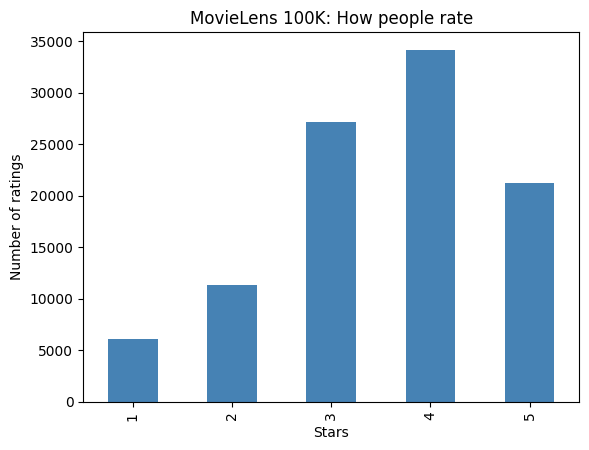

In [11]:
star_counts.plot(kind="bar", color="steelblue")

plt.xlabel("Stars")
plt.ylabel("Number of ratings")
plt.title("MovieLens 100K: How people rate")
plt.show()

The first line tells pandas to create a bar chart using star_counts.

The next three lines label the graph. plt.show() displays it.

The dataset has 100,000 ratings from 943 users on 1,682 movies. Ratings of 3 and 4 stars are most common, while 1-star ratings are least common. The average rating is about 3.53 stars. This suggests that people tend to rate movies they chose to watch, so ratings are somewhat skewed toward positive values.

In [12]:
R = ratings.pivot_table(
    index="user",
    columns="item",
    values="rating"
)

R

item,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
939,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
940,NaN,NaN,NaN,2.0,NaN,NaN,4.0,5.0,3.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
941,5.0,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


pivot_table reorganizes the data:
- index="user": each row represents one user.
- columns="item": each column represents one movie.
- values="rating": the entries are the star ratings.

Thus, \(R_{ij}\) is the rating that user \(i\) gave movie \(j\). If that user never rated that movie, the entry is NaN.
The whole table is too large to view comfortably, so Colab may show only part of it—that is fine.

In [13]:
print("Matrix shape:", R.shape)

fraction_missing = R.isna().to_numpy().mean()
print("Fraction missing:", round(fraction_missing, 4))

Matrix shape: (943, 1682)
Fraction missing: 0.937


- R.shape gives (number of rows, number of columns), so it should show (943, 1682).
- R.isna() marks each missing entry with True.
- .to_numpy() converts the labeled pandas table into an ordinary NumPy matrix.
- .mean() treats True as 1 and False as 0, so it gives the fraction of entries that are missing.

We get approximately 0.9370, meaning about 93.7% of possible user-movie ratings are missing.

In [14]:
per_user = ratings.groupby("user").size()

print("Least active user:", per_user.min())
print("Median user:", int(per_user.median()))
print("Most active user:", per_user.max())

Least active user: 20
Median user: 65
Most active user: 737


groupby("user") puts together all rows
belonging to the same user.

.size() counts the rows in each group, so per_user records each user’s number of ratings.

.min(), .median(), and .max() summarize those counts.

The user-by-movie matrix has shape \(943 \times 1682\): 943 users and 1,682 movies. About 93.7% of the entries are missing because most users have rated only a small subset of movies. The least active user rated 20 movies, the median user rated 65 movies, and the most active user rated 737 movies.

We cannot apply np.linalg.svd directly to \(R\) because it contains missing entries, represented by NaN. The SVD requires every matrix entry to be a numerical value. Predicting or filling in these missing ratings is the main goal of our recommendation system.

In [15]:
titles = pd.read_csv(
    "ml-100k/u.item",
    sep="|",
    encoding="latin-1",
    header=None,
    usecols=[0, 1],
    names=["item", "title"]
)

titles.head()

,item,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


This file contains information about each movie.
- sep="|" says the columns are separated by vertical bars.
- encoding="latin-1" is needed because some titles contain accented characters.
- header=None says the file has no row of column names at the top.
- usecols=[0, 1] keeps only the first two columns: the movie ID and title.
- names=["item", "title"] gives those two retained columns useful names.

In [16]:
stats = ratings.groupby("item")["rating"].agg(["count", "mean"])
stats = stats.join(titles.set_index("item"))

top_five = stats.sort_values("count", ascending=False).head(5)
top_five.round(2)

,count,mean,title
item,,,
50,583,4.36,Star Wars (1977)
258,509,3.80,Contact (1997)
100,508,4.16,Fargo (1996)
181,507,4.01,Return of the Jedi (1983)
294,485,3.16,Liar Liar (1997)


This makes one row per movie:
- count = how many users rated it
- mean = its average star rating
- .join(...) attaches its title
- sort_values("count", ascending=False) puts the most-rated movies first
- .head(5) keeps the top five

The five most-rated movies are shown in the table above; Star Wars (1977) is the most-rated movie. A ratings matrix may be approximately low rank because people’s tastes are often shaped by only a few hidden factors—for example, preference for action, comedy, romance, older films, or serious films. Each user has different strengths of these preferences, and each movie has different amounts of these features. Thus, a small number of underlying factors can explain many of the ratings.